Removed no burn in


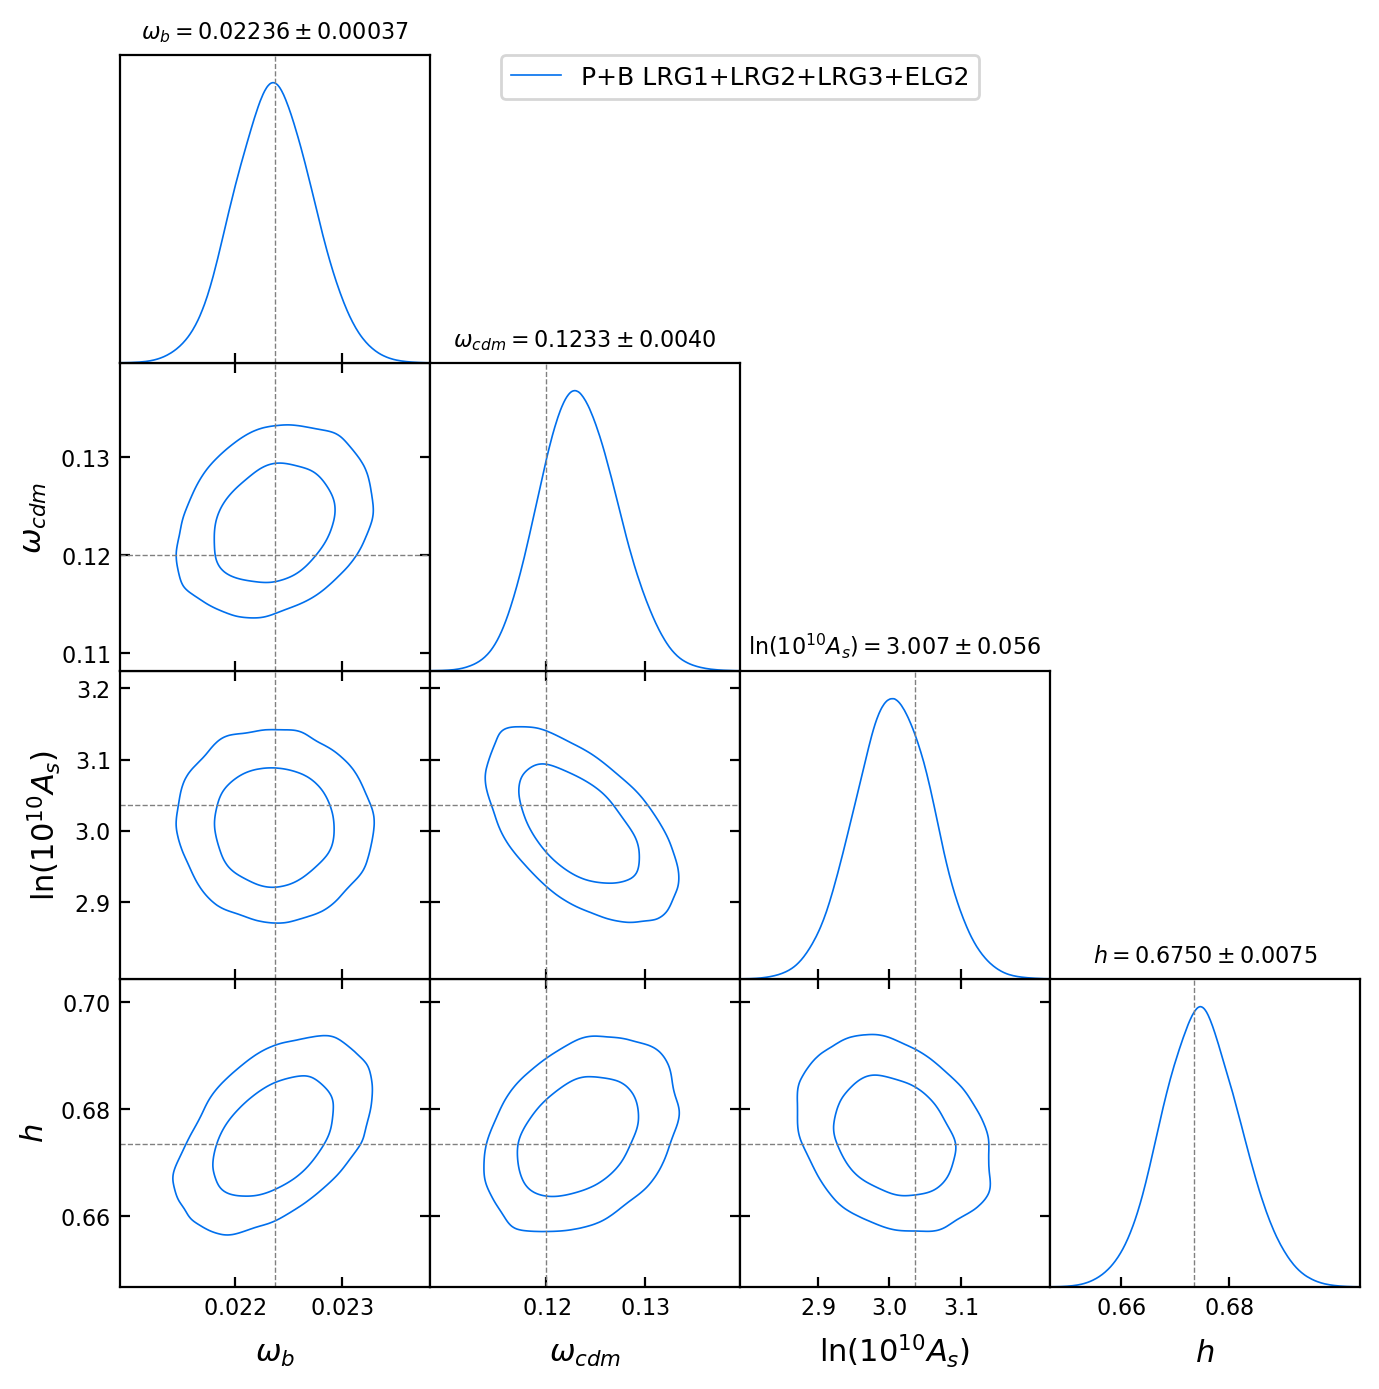

In [15]:
from desilike.samples import Chain, plotting
from pathlib import Path
from cosmoprimo.fiducial import AbacusSummit
import sys
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h']

cosmo = AbacusSummit()
truth = {p: cosmo[p] for p in params_toplot}
legends = []

BASE_DIR = Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-2ndgen-dr2-complete/cosmo-base_ns-fixed_LRG1-S2+LRG1-S3_LRG2-S2+LRG2-S3_LRG3-S2+LRG3-S3_ELG2-S2+ELG2-S3-bdc482b8/')

chain_fns = [BASE_DIR / f'chain_{i}.npy' for i in range(1)]
chain = Chain.concatenate([Chain.load(fn).remove_burnin(0.3)[::10] for fn in chain_fns])
# legends.append('LRG1-S2+LRG1-S3_LRG2-S2+LRG2-S3_LRG3-S2+LRG3-S3_ELG2-S2+ELG2-S3')
legends.append('P+B LRG1+LRG2+LRG3+ELG2')

plotting.plot_triangle(
    [chain],
    params=params_toplot,
    title_limit=1,
    markers=truth,
    legend_labels=legends
)
plt.show()